In [ ]:
from run_inference import *

def load_models(name="best", expt_id=None, device="cpu"):
    if expt_id is None:
        expt_id = experiment_id

    if name not in ["best", "last", "latest"]:
        raise NotImplementedError("Only `best`, `last`, and `latest` models are supported")
    
    if name=="best":
        suffix = ""
    else:
        suffix = f"_{name}"
    
    print(f"Loading `{name}` model")

    model = torch.load(f"models/{expt_id}/model{suffix}.pt", map_location=device, weights_only=False)
    scoremodel = torch.load(f"models/{expt_id}/scmodel{suffix}.pt", map_location=device, weights_only=False)
    embed_model = torch.load(f"models/{expt_id}/embed_model{suffix}.pt", map_location=device, weights_only=False)
    if os.path.exists(f"models/{expt_id}/preembed_model{suffix}.pt"):
        preembed_model = torch.load(f"models/{expt_id}/preembed_model{suffix}.pt", map_location=device, weights_only=False)
    else:
        tokenize_transform = lambda x: tokenize(x, args)[0]
        preembed_model = TransformInput(tokenize_transform).to(device)
    
    if os.path.exists(f"models/{expt_id}/aggregator{suffix}.pt"):
        aggregator = torch.load(f"models/{expt_id}/aggregator{suffix}.pt", map_location=device, weights_only=False)
    else:
        aggregator = None

    return model, scoremodel, embed_model, preembed_model, aggregator

@torch.no_grad()
def compute_scores(dataset, model, scoremodel, embed_model, preembed_model, image_embed_model=None, stagger=2, verbose=False, aggregator=None):
    loader = dataset.get_dataloader(batch_size=100, shuffle=True)

    C = embed_full_corpus(dataset, embed_model, preembed_model, image_embed_model=image_embed_model, aggregator=aggregator)
    # C is (N, n, xoutdim)

    normscores = []
    lamscores = []
    netscores = []
    true_labels = []
    for n, (q, l) in enumerate(tqdm(loader, leave=False, disable=not verbose)):
        q = q.to(next(model.parameters()).device) 
        # q is bmd, c is Nnd, l is bN
        q = q + batch_get_white_noise(q, args.SNR)     # torch.randn_like(q) * noise
        q = embed_if_image_and_normalize(q, image_embed_model)
        q = embed_model(preembed_model(q))
        q = normalize(q)
        # q is (b, m, xoutdim)
        if aggregator is None:
            qct = torch.einsum("bmd,Nnd->bNmn", q, C)
            if isinstance(model, LamModel):
                model_inputs = stagger_and_concat(qct, num_stagger=stagger) # bNsmn  s = num_stagger+1

                lambdas = torch.stack([model(x) for x in model_inputs])
                # bNm1
            else:
                lambdas = []
                for xx in range(len(q)):
                    q_ = q[xx].unsqueeze(0)
                    q_ = q_.repeat_interleave(C.shape[0], dim=0)
                    lambdas_ = model(torch.cat((q_, C), dim=1).flatten(start_dim=1)).unsqueeze(-1)
                    lambdas.append(lambdas_)
                lambdas = torch.stack(lambdas)

            F_mat = Rm_mat.T @ (2*qct + (a_vec @ lambdas.transpose(2,3) @ A_mat).transpose(2,3))

            P = gumbel_sinkhorn(F_mat, CFG.tau, CFG.n_sink_iter, noise=False)

            RmPC = Rm_mat @ P @ C.squeeze(-1)

            lamscore = lamwt * (lambdas.transpose(2,3) @ F.relu(b-A_mat @ Rm_mat @ P @ a_vec)).squeeze()
            normscore = torch.norm(q.unsqueeze(1) - RmPC, dim=[-1,-2])

            allscores = torch.stack([lamscore, normscore], dim=2)
            netscore = 2*scoremodel(-allscores).squeeze()      # b

        else:
            q = aggregator(q)
            # q is bd, C is Nd, we want bN scores
            # b1d - 1Nd = bNd --> sum across last dim to get bN scores
            netscore = 2 * F.sigmoid(-F.relu(q.unsqueeze(1) - C.unsqueeze(0)).sum(dim=-1))    # bN

        normscores.append(normscore.to('cpu'))
        lamscores.append(lamscore.to('cpu'))
        netscores.append(netscore.to('cpu'))
        true_labels.append(l.to('cpu'))

    netscores = torch.vstack(netscores)
    true_labels = torch.vstack(true_labels).squeeze() # 
    normscores = torch.vstack(normscores)
    lamscores = torch.vstack(lamscores)

    return netscores, normscores, lamscores, true_labels

In [2]:
# import pickle
# with open("all_scores.pkl", "rb") as file:
#     all_scores = pickle.load(file)

# pos_all = all_scores["pos"]
# neg_all = all_scores["neg"]

# for expt_id in ["C30082224", "A01091914", "AH05092001", "L13090014"][3:]:
#     args = argparse.Namespace(expt_id=expt_id, device=0)

#     experiment_id = args.expt_id
#     expt_root = f"models/{experiment_id}/"
#     args.device = 1
#     DEVICE = f"cuda:0" if torch.cuda.is_available() and args.device != -1 else "cpu"

#     with open(os.path.join(expt_root, "args.pkl"), "rb") as file:
#         args = pickle.load(file)

#     model, scoremodel, embed_model, preembed_model, aggregator = load_models(name="best", expt_id=experiment_id, device=DEVICE)
#     model.eval(), scoremodel.eval(), embed_model.eval(), preembed_model.eval()
#     if aggregator is not None:
#         aggregator.eval()

#     nwt, lamwt = next(scoremodel.parameters()).exp().detach().cpu()
#     nwt, lamwt = nwt.item(), lamwt.item()

#     print(f"normscore weight: {nwt:.4f}, lamscore weight: {lamwt:.4f}")

#     dataset = args.dataset 
#     dataset = "speech" if dataset == "human" else dataset
#     dataset = "lsun" if dataset == "lsun384" else dataset
#     DATA_ROOT = f"final_data/{dataset}"
#     TEST_FILE = f"{DATA_ROOT}/dataset_test.hdf5"
#     NOLAMMODEL = args.__dict__.get("no_lammodel", False)

#     image_embed_model = None
#     if "cifar" in dataset:
#         image_embed_model_ckpt = "data/image_sequence/embedding_models/cifar_ae.pkl"
#         image_embed_model = Autoencoder()
#         image_embed_model.load_state_dict(torch.load(image_embed_model_ckpt))
#         image_embed_model.eval()

#         for param in image_embed_model.parameters():
#             param.requires_grad = False

#         image_embed_model = image_embed_model.to(DEVICE)
#         TEST_FILE = f"{DATA_ROOT}/dataset_test_orig.hdf5"

#     if "lsun" in dataset:
#         image_embed_model_ckpt = "data/image_sequence/embedding_models/lsun_ae.pkl"
#         image_embed_model = LSUNAutoencoder()
#         image_embed_model.load_state_dict(torch.load(image_embed_model_ckpt))
#         image_embed_model.eval()

#         for param in image_embed_model.parameters():
#             param.requires_grad = False

#         image_embed_model = image_embed_model.to(DEVICE)
#         TEST_FILE = f"{DATA_ROOT}/dataset_test_orig.hdf5"

#     test_dataset = PairDatasetTest(TEST_FILE)
#     print(f"test subset of dataset: \"{dataset}\" loaded from {TEST_FILE}")

#     ##### HPARAMS ######
#     b = args.b          # hinge margin for negative gap penalty (b-Apa)
#     b1 = args.b1         # hinge margin for positive gap penalty (Apa-b)
#     delta = args.delta     # hinge margin for contrastive loss
#     lr = args.lr
#     nepochs = args.nepochs
#     stagger = args.stagger
#     lamwt = args.lamwt    # loss coefficient for negative gap penalty
#     gapwt = args.gapwt       # loss coefficient for positive gap penalty
#     M = 6
#     N = 20
#     ####################

#     A_mat, a_vec, Rm_mat = get_opas_constants(M, N, DEVICE)

#     CFG = AttributeDict({
#         'tau': 1,
#         'n_sink_iter': 20,
#         'n_samples': 1,
#     })

#     netscores, normscores, lamscores, true_labels = compute_scores(test_dataset, model, scoremodel, embed_model, preembed_model, image_embed_model=image_embed_model, stagger=stagger, verbose=True, aggregator=aggregator)

#     print(netscores.shape, normscores.shape, lamscores.shape, true_labels.shape)

#     all_pos_scores = [
#         netscores[true_labels==1],
#         normscores[true_labels==1],
#         lamscores[true_labels==1]
#     ]
#     all_neg_scores = [
#         netscores[true_labels==0],
#         normscores[true_labels==0],
#         lamscores[true_labels==0]
#     ]

#     pos_all[dataset] = all_pos_scores
#     neg_all[dataset] = all_neg_scores

In [3]:
# all_scores = {
#     "pos": pos_all,
#     "neg": neg_all
# }
# with open("all_scores.pkl", "wb") as file:
#     pickle.dump(all_scores, file)

In [1]:
import seaborn as sns
from plot_params import *

# from matplotlib import font_manager
# import matplotlib.pyplot as plt
# import matplotlib as mpl

# font = font_manager.FontEntry(fname="plots_and_figures/arial.ttf", name="Arial")
# font_manager.fontManager.ttflist.append(font)

# mpl.rcParams['font.family'] = "Arial"

# Only final scores

In [2]:
import pickle
with open("all_scores.pkl", "rb") as file:
    all_scores = pickle.load(file)

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.stats import gaussian_kde


def draw_hatch_lines(ax, x0, x1, y0, y1, hatch="//", hatch_color="white",
                     hatch_linewidth=1.0, hatch_spacing=6):
    """
    Manually draw hatch lines clipped to a bar rectangle, producing
    only simple Line2D objects — no PDF tiling paths.

    hatch_spacing : gap between lines in points
    """
    from matplotlib.patches import Rectangle
    from matplotlib.transforms import Bbox
    import matplotlib.patheffects as pe

    width  = x1 - x0
    height = y1 - y0

    # convert hatch_spacing from points to data units via the axes transform
    inv = ax.transData.inverted()
    p0  = inv.transform(ax.transData.transform([x0, y0]))
    p1  = inv.transform(ax.transData.transform([x0, y0]) + np.array([hatch_spacing, hatch_spacing]))
    dx  = abs(p1[0] - p0[0])
    dy  = abs(p1[1] - p0[1])

    lines = []
    if "/" in hatch:
        # diagonal lines bottom-left to top-right
        # sweep start points along bottom edge then left edge
        starts_x = np.arange(x0, x1 + width,  dx)
        starts_y = np.arange(y0, y1 + height, dy)
        starts   = ([(sx, y0) for sx in starts_x] +
                    [(x0, sy) for sy in starts_y])
        for sx, sy in starts:
            # line goes up-right at 45°; clip to [x0,x1] x [y0,y1]
            ex = sx + width + height
            ey = sy + width + height
            # clip x to bar
            if ex > x1: ey -= (ex - x1); ex = x1
            if sx < x0: sy += (x0 - sx); sx = x0
            if ey > y1: ex -= (ey - y1); ey = y1
            if sy < y0: continue
            if ex <= sx or ey <= sy: continue
            line = mlines.Line2D([sx, ex], [sy, ey],
                                 color=hatch_color, linewidth=hatch_linewidth,
                                 transform=ax.transData, clip_on=True)
            line.set_clip_path(Rectangle((x0, y0), width, height,
                                          transform=ax.transData))
            ax.add_line(line)
            lines.append(line)

    if "\\" in hatch:
        starts_x = np.arange(x0 - width, x1 + dx, dx)
        starts_y = np.arange(y0, y1 + height, dy)
        starts   = ([(sx, y0) for sx in starts_x] +
                    [(x1, sy) for sy in starts_y])
        for sx, sy in starts:
            ex = sx - (width + height)
            ey = sy +  width + height
            if ex < x0: ey -= (x0 - ex) ; ex = x0  # noqa
            if sx > x1: sy += (sx - x1) ; sx = x1  # noqa
            if ey > y1: ex += (ey - y1) ; ey = y1  # noqa
            if sy < y0: continue
            if sx <= ex or ey <= sy: continue
            line = mlines.Line2D([sx, ex], [sy, ey],
                                 color=hatch_color, linewidth=hatch_linewidth,
                                 transform=ax.transData, clip_on=True)
            line.set_clip_path(Rectangle((x0, y0), width, height,
                                          transform=ax.transData))
            ax.add_line(line)
            lines.append(line)

    return lines

import seaborn as sns

def histplot_with_kde_sns(data, ax=None, bins="auto", color="steelblue", hatch_color="white",
                      hatch="//", hatch_linewidth=1.0,
                      hatch_spacing=6, label=None):

    if ax is None:
        ax = plt.gca()

    kwargs = {
        "kde": True, 
        "stat": "probability",
        "element": "step", 
        "common_norm": False,
        "alpha": 0.7,
        # "bins": 50
    }

    sns.histplot(data, ax=ax, bins=bins, color=color,
                 label=label, linewidth=0.5, **kwargs)

    # sns.histplot draws Rectangle patches on the axes — grab them
    for bar in ax.patches:
        x0 = bar.get_x()
        x1 = x0 + bar.get_width()
        y0 = bar.get_y()
        y1 = y0 + bar.get_height()
        if y1 == y0:  # skip zero-height bars
            continue
        draw_hatch_lines(ax, x0, x1, y0, y1,
                         hatch=hatch, hatch_color=hatch_color,
                         hatch_linewidth=hatch_linewidth,
                         hatch_spacing=hatch_spacing)

    return ax


def histplot_with_kde(data, ax=None, bins="auto", color="steelblue", hatch_color="white",
                      hatch="//", alpha=0.6, linewidth=2, hatch_linewidth=1.0,
                      hatch_spacing=6, label=None):
    from scipy.stats import gaussian_kde

    if ax is None:
        ax = plt.gca()

    # draw bars without any matplotlib hatch
    _, bin_edges, bars = ax.hist(data, bins=bins, density=True,
                                 color=color, alpha=alpha, label=label,
                                 edgecolor="none")

    # manually hatch each bar
    for bar in bars:
        x0 = bar.get_x()
        x1 = x0 + bar.get_width()
        y0 = 0
        y1 = bar.get_height()
        draw_hatch_lines(ax, x0, x1, y0, y1,
                         hatch=hatch, hatch_color=hatch_color,
                         hatch_linewidth=hatch_linewidth,
                         hatch_spacing=hatch_spacing)

    # KDE
    kde = gaussian_kde(data)
    x   = np.linspace(np.min(data), np.max(data), 300)
    ax.plot(x, kde(x), color=color, linewidth=linewidth, zorder=3)

    return ax

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.patches import Rectangle, PathPatch
from matplotlib.path import Path
from scipy.stats import gaussian_kde


def draw_hatch_lines_global(ax, bars, hatch="//", hatch_color="white",
                             hatch_linewidth=1.0, hatch_spacing=6):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # work entirely in display (pixel) space so the angle is truly 45°
    trans      = ax.transData
    inv        = trans.inverted()

    # axes corners in display space
    disp_bl = trans.transform([xmin, ymin])
    disp_tr = trans.transform([xmax, ymax])
    disp_w  = disp_tr[0] - disp_bl[0]
    disp_h  = disp_tr[1] - disp_bl[1]
    disp_span = disp_w + disp_h   # enough to cover full diagonal

    # sweep start points along the bottom edge in display space
    starts_disp = np.arange(disp_bl[0] - disp_h, disp_tr[0] + disp_h, hatch_spacing)

    # union clip path from all bars (in data coords, matplotlib handles the transform)
    bar_rects = [(bar.get_x(), bar.get_y(), bar.get_width(), bar.get_height())
                 for bar in bars if bar.get_height() > 0]
    if not bar_rects:
        return

    verts, codes = [], []
    for bx, by, bw, bh in bar_rects:
        verts += [(bx,      by     ),
                  (bx + bw, by     ),
                  (bx + bw, by + bh),
                  (bx,      by + bh),
                  (bx,      by     )]
        codes += [Path.MOVETO, Path.LINETO, Path.LINETO,
                  Path.LINETO, Path.CLOSEPOLY]

    clip_path = PathPatch(Path(verts, codes), transform=ax.transData)
    ax.add_patch(clip_path)
    clip_path.set_visible(False)

    for sx in starts_disp:
        if "/" in hatch:
            # bottom-left to top-right in display space → convert to data
            p0 = inv.transform([sx,             disp_bl[1]])
            p1 = inv.transform([sx + disp_span, disp_bl[1] + disp_span])
        else:
            # top-left to bottom-right
            p0 = inv.transform([sx,             disp_tr[1]])
            p1 = inv.transform([sx + disp_span, disp_tr[1] - disp_span])

        line = mlines.Line2D([p0[0], p1[0]], [p0[1], p1[1]],
                             color=hatch_color, linewidth=hatch_linewidth,
                             transform=ax.transData, clip_on=True)
        line.set_clip_path(clip_path)
        ax.add_line(line)
        

def histplot_with_kde(data, ax=None, bins="auto", color="steelblue", hatch_color="white",
                      hatch="//", alpha=0.6, linewidth=2, hatch_linewidth=1.0,
                      hatch_spacing=6, label=None):
    if ax is None:
        ax = plt.gca()

    _, bin_edges, bars = ax.hist(data, bins=bins, density=True,
                                 color=color, alpha=alpha, label=label,
                                 edgecolor="none")

    def on_draw(event):
        draw_hatch_lines_global(ax, bars,
                                hatch=hatch, hatch_color=hatch_color,
                                hatch_linewidth=hatch_linewidth,
                                hatch_spacing=hatch_spacing)
        ax.figure.canvas.mpl_disconnect(cid)

    cid = ax.figure.canvas.mpl_connect("draw_event", on_draw)

    kde = gaussian_kde(data)
    x   = np.linspace(np.min(data), np.max(data), 300)
    ax.plot(x, kde(x), color=color, linewidth=linewidth, zorder=3)

    return ax

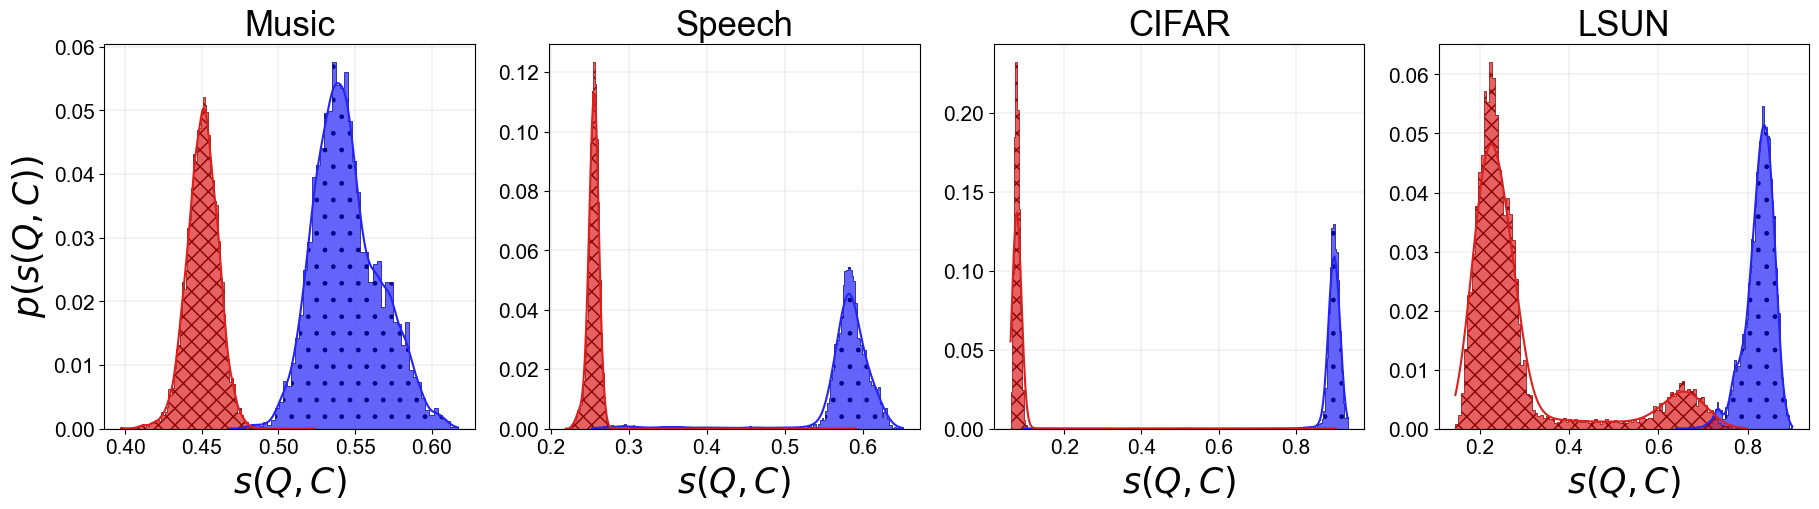

In [82]:
pos_all, neg_all = all_scores["pos"], all_scores["neg"]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes = axes.flatten()

kwargs = {
    "kde": True, 
    "stat": "probability",
    "element": "step", 
    "common_norm": False,
    "alpha": 0.7,
    # "bins": 50
}

myblue = "#2323fa"
myred = "#dc2020"

plot_markersize = 10
opas_markersize = 250
opas_idmarkersize = 200
axis_fontsize = 25
title_fontsize = 25
label_fontsize = 15
legend_fontsize = 20

xfm = lambda x: x.capitalize() if x not in ["cifar", "lsun"] else x.upper()

np.random.seed(0)
for n, dataset in enumerate(["audio", "speech", "cifar", "lsun"]):
    ps, ns = pos_all[dataset][0], neg_all[dataset][0] 
    dataset = "music" if dataset == "audio" else dataset
    # ps: 20_000, ns: 1_980_000
    # sns.histplot(np.random.choice(ps, 1000, replace=False), ax=axes[n], color=myblue, label=r"$s(Q^+,C)$", hatch='//', edgecolor='darkblue', linewidth=0.5, **kwargs)
    # histplot_with_kde(np.random.choice(ps, 1000, replace=False), ax=axes[n], color=myblue, label=r"$s(Q^+,C)$", hatch="/", alpha=0.7, hatch_color="darkblue", hatch_spacing=20, hatch_linewidth=1)
    # histplot_with_kde(np.random.choice(ns, 1000, replace=False), ax=axes[n], color=myred, label=r"$s(Q^-,C)$", hatch="\\", alpha=0.7, hatch_color="darkred", hatch_spacing=20, hatch_linewidth=1)
    # histplot_with_kde(np.random.choice(ns, 1000, replace=False), ax=axes[n], color=myred, label=r"$s(Q^-,C)$", hatch="\\", hatch_color="darkred")
    sns.histplot(np.random.choice(ps, 10000, replace=False), ax=axes[n], color=myblue, label=r"$s(Q^+,C)$", hatch='.', edgecolor='darkblue', linewidth=0.5, **kwargs)
    sns.histplot(np.random.choice(ns, 10000, replace=False), ax=axes[n], color=myred, label=r"$s(Q^-,C)$", hatch='xx', edgecolor='darkred', linewidth=0.5, **kwargs)
    # axes[n].legend(loc='upper right', fontsize=15)
    if n == 0:
        axes[n].set_ylabel(r"$p(s(Q,C))$", fontsize=axis_fontsize)
    else:
        axes[n].set_ylabel("")
    axes[n].set_xlabel(r"$s(Q,C)$", fontsize=axis_fontsize)
    axes[n].set_title(f"{xfm(dataset)}", fontsize=title_fontsize)
    axes[n].tick_params(axis='both', which='major', labelsize=label_fontsize)
    axes[n].grid(linewidth=0.2)
    axes[n].set_axisbelow(True)
    # axes[n].set_rasterized(True)

    handles, labels = axes[n].get_legend_handles_labels()
    # break

legend = fig.legend(handles, labels, loc='upper center', ncol=5, fontsize=legend_fontsize)
coords = legend.get_window_extent().get_points()[0]
fig.legends = []
scale = fig.get_window_extent().get_points()[1]
# fig.legend(handles, labels, bbox_to_anchor=(coords[0]/(scale[0]), coords[1]/(scale[1])+legend_fontsize/80), loc=2, ncol=5, fontsize=legend_fontsize)
fig.savefig('score_distribution_sqc_hatched.pdf', bbox_inches='tight', backend='pgf')
# fig.savefig(r'C:\Users\bhavy\Downloads\aistats_paper_checker_v011\testing.pdf', bbox_inches='tight', backend='pgf')
plt.show()

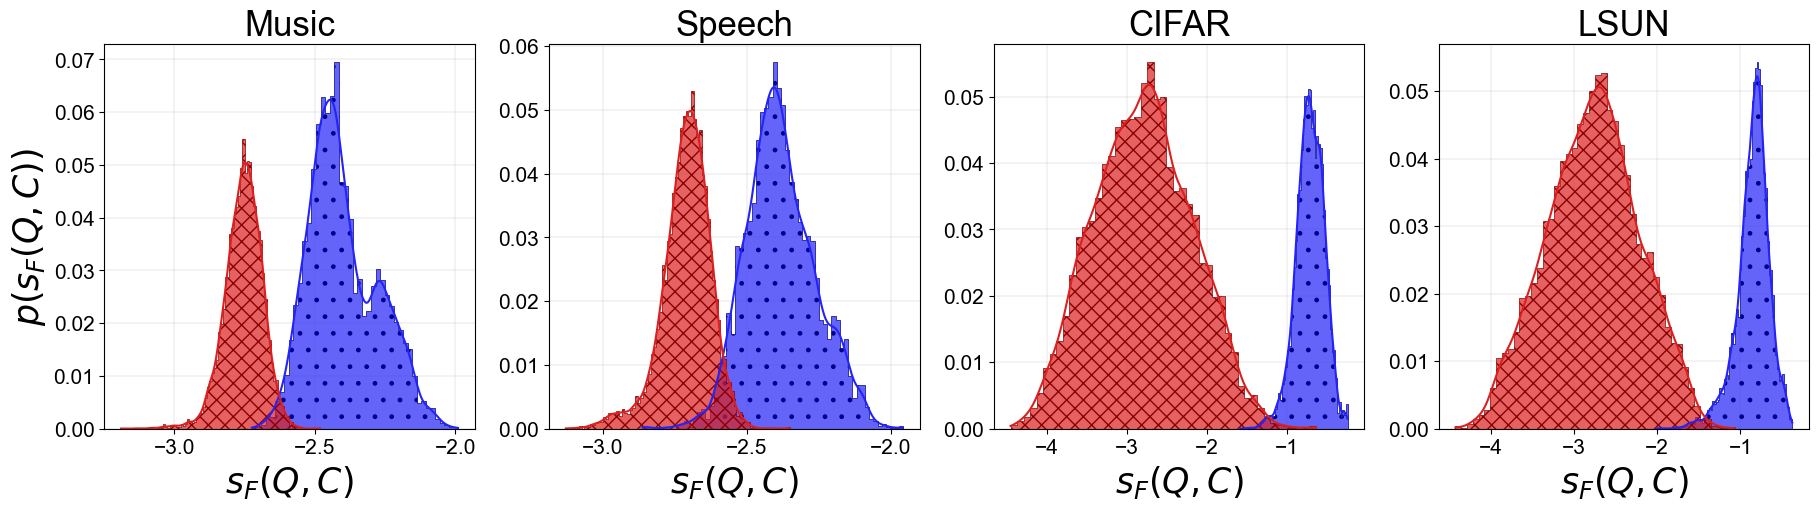

In [80]:
# import pickle
# with open("all_scores.pkl", "rb") as file:
#     all_scores = pickle.load(file)

pos_all, neg_all = all_scores["pos"], all_scores["neg"]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes = axes.flatten()

xfm = lambda x: x.capitalize() if x not in ["cifar", "lsun"] else x.upper()

np.random.seed(0)
for n, dataset in enumerate(["audio", "speech", "cifar", "lsun"]):
    ps, ns = pos_all[dataset][1], neg_all[dataset][1]
    dataset = "music" if dataset == "audio" else dataset
    # ps: 20_000, ns: 1_980_000
    sns.histplot(np.random.choice(-ps, 10_000, replace=False), ax=axes[n], color=myblue, label=r"$s_{F}(Q^+,C)$", hatch='.', edgecolor='darkblue', linewidth=0.5, **kwargs)
    sns.histplot(np.random.choice(-ns, 10_000, replace=False), ax=axes[n], color=myred, label=r"$s_{F}(Q^-,C)$", hatch='xx', edgecolor='darkred', linewidth=0.5, **kwargs)

    # axes[n].legend(loc='upper right', fontsize=15)
    if n == 0:
        # axes[n].set_ylabel(r"$p(s(Q,C))$", fontsize=axis_fontsize)
        axes[n].set_ylabel(r"$p(s_{F}(Q,C))$", fontsize=axis_fontsize)
    else:
        axes[n].set_ylabel("")
    # axes[n].set_xlabel(r"$s(Q,C)$", fontsize=axis_fontsize)
    axes[n].set_xlabel(r"$s_{F}(Q,C)$", fontsize=axis_fontsize)
    axes[n].set_title(f"{xfm(dataset)}", fontsize=title_fontsize)
    axes[n].tick_params(axis='both', which='major', labelsize=label_fontsize)
    axes[n].grid(linewidth=0.2)
    axes[n].set_axisbelow(True)

    handles, labels = axes[n].get_legend_handles_labels()

legend = fig.legend(handles, labels, loc='upper center', ncol=5, fontsize=legend_fontsize)
coords = legend.get_window_extent().get_points()[0]
fig.legends = []
scale = fig.get_window_extent().get_points()[1]
# fig.legend(handles, labels, bbox_to_anchor=(coords[0]/(scale[0]), coords[1]/(scale[1])+legend_fontsize/80), loc=2, ncol=5, fontsize=legend_fontsize)
fig.savefig('score_distribution_normqc_hatched.pdf', bbox_inches='tight', backend='pgf')
# fig.savefig(r'C:\Users\bhavy\Downloads\aistats_paper_checker_v011\testing.pdf', bbox_inches='tight', backend='pgf')
plt.show()

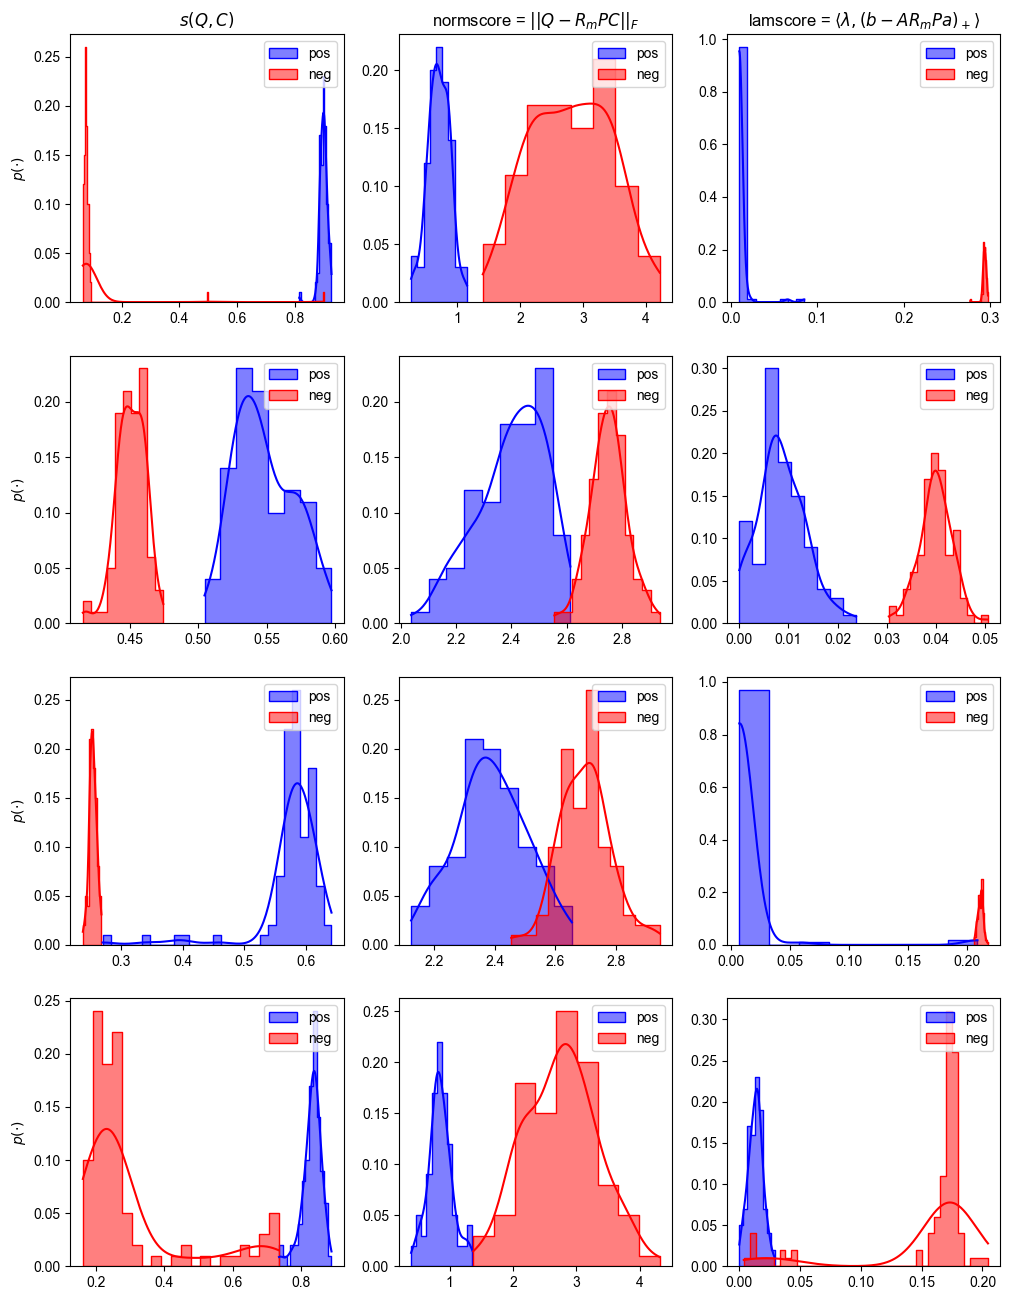

In [ ]:
import pickle
with open("plots_and_figures/all_scores.pkl", "rb") as file:
    all_scores = pickle.load(file)

pos_all, neg_all = all_scores["pos"], all_scores["neg"]

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

kwargs = {
    "kde": True, 
    "stat": "probability",
    "element": "step", 
    "common_norm": False,
}

for n,dataset in enumerate(pos_all.keys()):
    ps, ns = pos_all[dataset], neg_all[dataset]
    for i, (pss, nss) in enumerate(zip(ps, ns)):
        sns.histplot(np.random.choice(pss, 100, replace=False), ax=axes[n][i], color='b', label="pos", **kwargs)
        sns.histplot(np.random.choice(nss, 100, replace=False), ax=axes[n][i], color='r', label="neg", **kwargs)
        if n==0:
            labels = [r'$s(Q,C)$', r'normscore = $||Q-R_mPC||_F$', r'lamscore = $\langle \lambda, (b - AR_mPa)_+ \rangle$']
            axes[n][i].set_title(f"{labels[i]}")
        axes[n][i].legend(loc='upper right')
        if i > 0:
            axes[n][i].set_ylabel("")
        else:
            axes[n][i].set_ylabel(r"$p(\cdot)$")
        # axes[n][i].text(0.5, 0.9, f"{dataset.upper()}", fontsize=14, ha='center', va='center', transform=axes[n][i].transAxes)
    # raise

In [ ]:
import pickle
with open("all_scores.pkl", "rb") as file:
    all_scores = pickle.load(file)

pos_all, neg_all = all_scores["pos"], all_scores["neg"]

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

kwargs = {
    "kde": True, 
    "stat": "probability",
    "element": "step", 
    "common_norm": False,
}

for n,dataset in enumerate(pos_all.keys()):
    ps, ns = pos_all[dataset], neg_all[dataset]
    for i, (pss, nss) in enumerate(zip(ps, ns)):
        sns.histplot(np.random.choice(pss, 100, replace=False), ax=axes[n][i], color='b', label="pos", **kwargs)
        sns.histplot(np.random.choice(nss, 100, replace=False), ax=axes[n][i], color='r', label="neg", **kwargs)
        if n==0:
            labels = ["Net Score", "normscore", "lamscore"]
            axes[n][i].set_title(f"{labels[i]}")
        axes[n][i].legend(loc='upper right')
        if i > 0:
            axes[n][i].set_ylabel("")
        else:
            axes[n][i].set_ylabel(r"$p(\cdot)$")

        xlabels = [r"$s(Q,C)$", r"$||Q-R_mPC||_F$", r"$\langle \lambda, (b - AR_mPa)_+ \rangle$"]
        axes[n][i].set_xlabel(f"{xlabels[i]}")
        # axes[n][i].text(0.5, 0.9, f"{dataset.upper()}", fontsize=14, ha='center', va='center', transform=axes[n][i].transAxes)
    # raise